# Data Visualization
1. now we will do geospation analysis based on the neighborhood data
2. join with our citibike data,
3. visualize top routes
   
    A. change width

    B.change color
    
4. Choropleth Maps

## Loading Libraries

In [4]:
import requests
import pandas as pd

import plotly.express as px
import folium

import os
from pathlib import Path
from urllib.request import urlretrieve
from urllib.parse import urlencode
from urllib.error import HTTPError, URLError
from zipfile import ZipFile

import geopandas as gpd


## Read and Visualize `jersey-city-neighborhoods.geojson` data

In [ ]:
geojson_url = 'https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/citibike/JC/jersey-city-neighborhoods.geojson'
OUTPUT_DIR = "../data/JC/"

In [16]:
gdf = gpd.read_file(geojson_url)
gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


### Data enrichment

In [17]:
# 2. Convert Square Feet to Square Kilometers
# gdf["area_sq_km"] = gdf["area_sq_m"] / 1,000,000

gdf["area_sq_km"] = gdf["area_sq_ft"] * 0.00000009290304

gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,area_sq_km
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",38.23902
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",38.23902
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",38.23902
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",38.23902
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",38.23902


### Store geodata

In [25]:
url = f'{OUTPUT_DIR}/jersey-city-neighborhoods.geojson'
gdf.to_file(url, driver="GeoJSON")

### Read geodata from the folder and inspect

In [27]:
url = f'{OUTPUT_DIR}/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,area_sq_km,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,38.23902,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,38.23902,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,38.23902,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,38.23902,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,38.23902,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [28]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   area_sq_km    53 non-null     float64 
 9   geometry      53 non-null     geometry
dtypes: float64(6), geometry(1), int32(1), str(2)
memory usage: 4.1 KB


In [29]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [31]:
jersey_city = jersey_city.to_crs("EPSG:4326")


<Axes: >

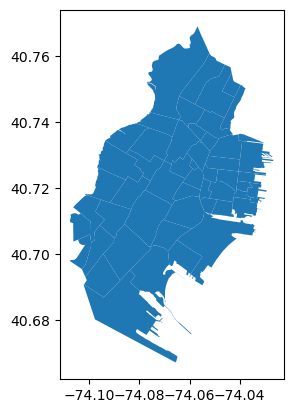

In [33]:
jersey_city.plot()

### Read Rides Data

In [34]:
citybike_df = pd.read_csv(f"{OUTPUT_DIR}/JC2025_Enriched.csv")
citybike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


### Station Level Summary

#### Start stations

In [36]:
start_stations = citybike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

#### End stations

In [ ]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()